In [1]:
#!/usr/bin/env python3
# count_unique.py
#
# usage:
#   python count_unique.py smiles_inchi.csv
#
# Reads the CSV produced earlier (with columns "smiles" and "inchi"),
# then prints:
#   • number of unique SMILES strings
#   • number of unique InChI strings
#   • number of unique (SMILES, InChI) pairs

import csv
import sys
from pathlib import Path

def count_unique(csv_path: Path):
    unique_smiles = set()
    unique_inchi  = set()
    unique_pairs  = set()

    with csv_path.open(newline='', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            s = row.get('smiles', '').strip()
            i = row.get('inchi',  '').strip()
            if s:
                unique_smiles.add(s)
            if i:
                unique_inchi.add(i)
            if s or i:
                unique_pairs.add((s, i))

    return len(unique_smiles), len(unique_inchi), len(unique_pairs), 

def main():
    csv_file = Path("../data/smiles_inchi.csv")
    if not csv_file.exists():
        sys.exit(f"Error: file not found: {csv_file}")

    n_smiles, n_inchi, n_pairs = count_unique(csv_file)
    print(f"Unique SMILES: {n_smiles}")
    print(f"Unique InChI:  {n_inchi}")
    print(f"Unique pairs:  {n_pairs}")
    

if __name__ == "__main__":
    main()


Unique SMILES: 6010
Unique InChI:  6089
Unique pairs:  6120


In [2]:
# Cell 1: 必要なライブラリのインポート
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Draw import MolsToGridImage
from IPython.display import display

In [3]:
# Cell 2: CSV の読み込みと RDKit Mol オブジェクトの生成
# ファイル名は適宜変更してください
csv_path = '../data/smiles_inchi.csv'
df = pd.read_csv(csv_path, dtype=str).fillna('')

mols = []
for smi in df['smiles']:
    if smi:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            print(f"Warning: invalid SMILES '{smi}'")
        mols.append(mol)
    else:
        mols.append(None)

legends = df['smiles'].tolist()


/fast/app/anaconda3/envs/muto_neims/lib/python3.6/site-packages/rdkit/Chem/Draw/IPythonConsole.py:192: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  % (maxMols))


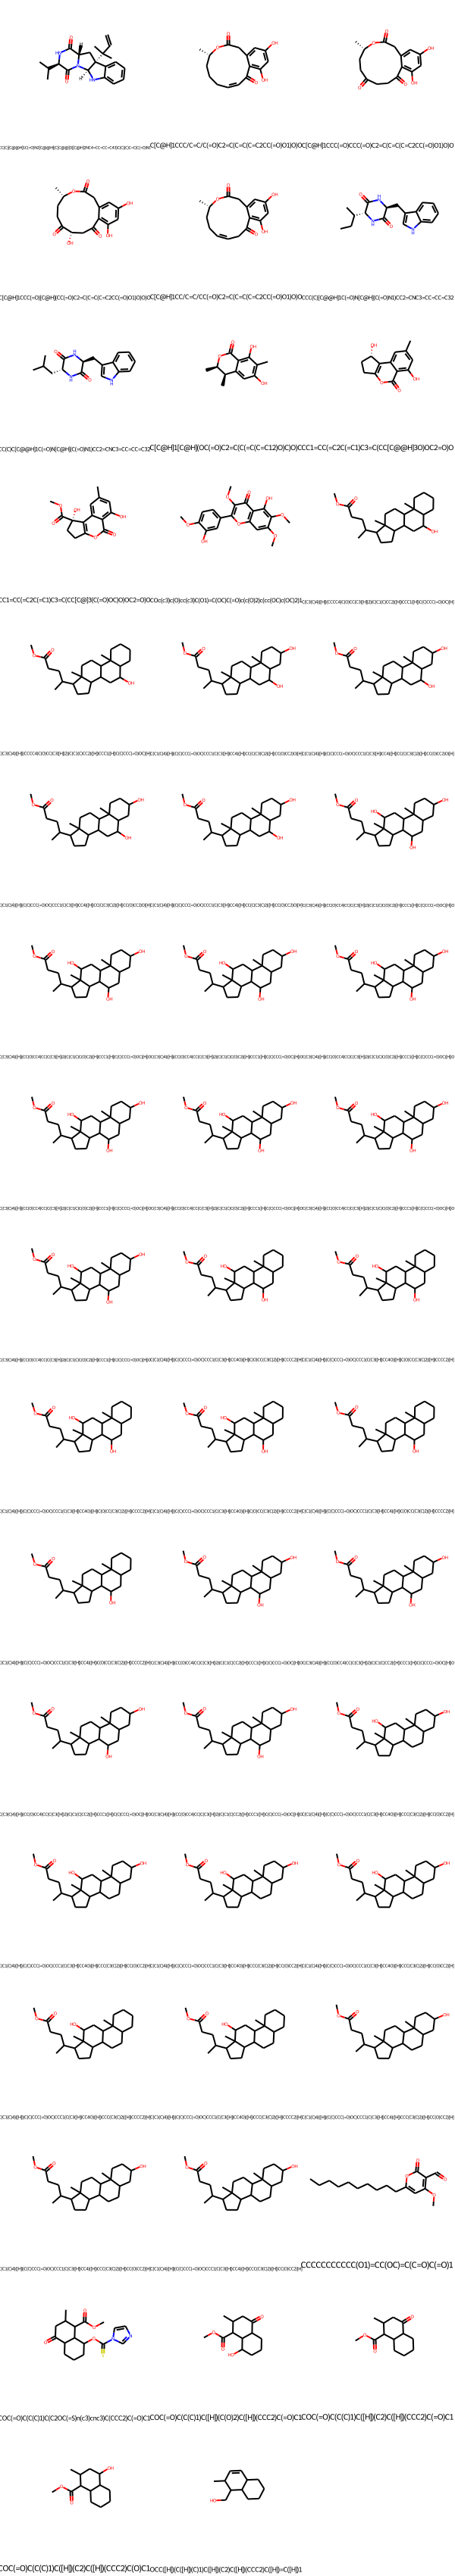

In [4]:
# Cell 3: 分子をグリッド表示
# None はスキップ
valid = [(m, lg) for m, lg in zip(mols, legends) if m is not None]
if valid:
    mol_list, leg_list = zip(*valid)
    img = MolsToGridImage(
        mol_list,
        legends=leg_list,
        molsPerRow=3,      # 1行あたりの分子数
        subImgSize=(200,200)
    )
    display(img)
else:
    print("表示できる分子がありません。")


--- Compound #52: Fc(c3)c(ccc3)C(=O)C(C(=O)2)C(=NO2)c(c1)cccc1 ---


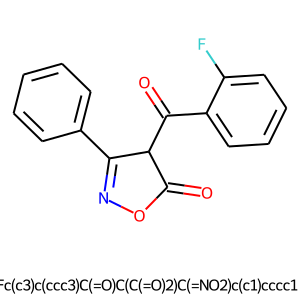

--- Compound #53: Fc(c3)ccc(c3)C(=O)C(C(=O)2)C(=NO2)c(c1)cccc1 ---


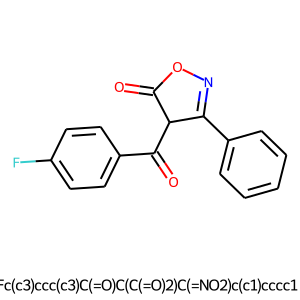

--- Compound #54: Fc(c3)cc(cc3)C(=O)C(C(=O)2)C(=NO2)c(c1)cccc1 ---


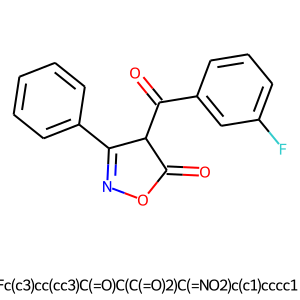

--- Compound #55: c(c3)ccc(c3)C(=N2)C(C(=O)O2)C(=O)c(c(F)1)c(F)ccc1 ---


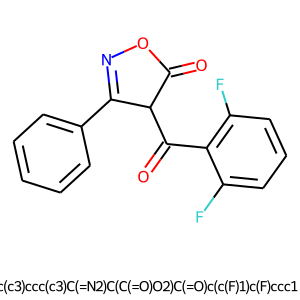

--- Compound #60: Fc(c3)cc(F)c(c3)C(=O)C(C(=O)2)C(=NO2)c(c1)cccc1 ---


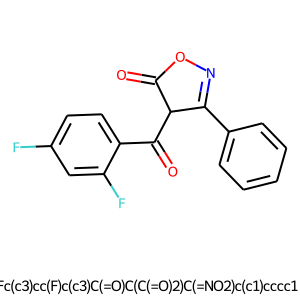

--- Compound #61: c(c3)ccc(c3)C(=N2)C(C(=O)O2)C(=O)c(c(F)1)c(F)c(F)c(F)c(F)1 ---


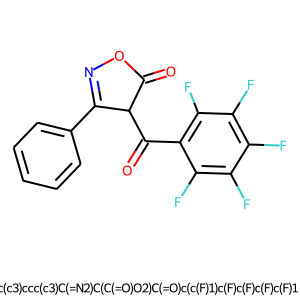

--- Compound #62: Fc(c3)ccc(c3)C(=O)C(C(=O)2)C(=NO2)c(c1)cccc1 ---


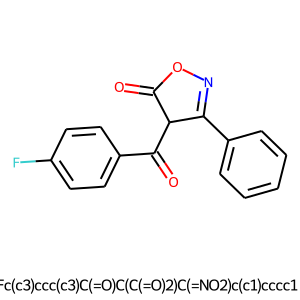

--- Compound #197: BrCc(c1)cc(cc1C(F)(F)F)C(F)(F)F ---


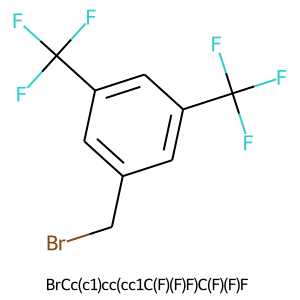

--- Compound #258: Fc(c1)cc(C)c(F)c1 ---


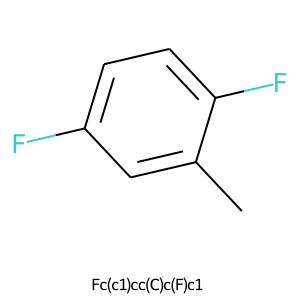

--- Compound #259: Cc(c1)cc(F)c(F)c1 ---


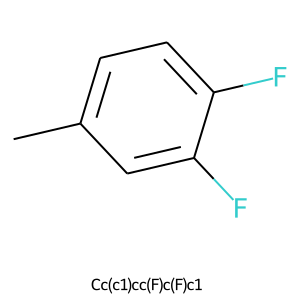

In [5]:
counter = 0

for idx, (mol, lg) in enumerate(zip(mols, legends), start=1):
    # Molオブジェクトがあり、かつSMILESに'F'が含まれる場合のみ描画
    if mol is None or 'F' not in lg:
        continue

    img = MolsToGridImage(
        [mol],
        legends=[lg],
        molsPerRow=1,
        subImgSize=(300, 300)
    )
    print(f"--- Compound #{idx}: {lg} ---")
    display(img)
    counter += 1

    if counter >= 10:  # 最初の10個だけ表示
        break

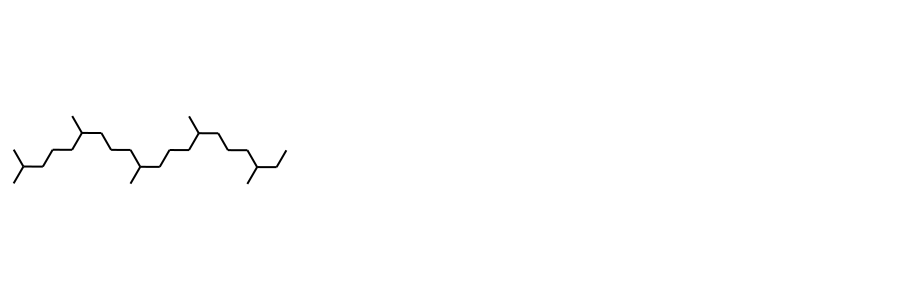

In [ ]:
# smilesを入力して構造式を表示する関数
def display_mol_from_smiles(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(f"Warning: invalid SMILES '{smi}'")
        return
    img = MolsToGridImage([mol], subImgSize=(300, 300))
    display(img)

smi = ''
display_mol_from_smiles(smi)